In [1]:
!nvidia-smi

Tue Jun 23 00:32:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# !git clone https://github.com/Omid-Nejati/Locality-iN-Locality.git

!git clone https://github.com/huongng389/Locality-iN-Locality.git

Cloning into 'Locality-iN-Locality'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 64 (delta 20), reused 19 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 61.67 KiB | 4.74 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [3]:
cd /content/Locality-iN-Locality

/content/Locality-iN-Locality


In [4]:
pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 14.0 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: req

In [5]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary

In [6]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.11.0+cu128
Torchvision 0.26.0+cu128
Torchattacks 3.5.1
Numpy 2.0.2


## GTSRB

In [7]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0  16.8M      0  0:00:15  0:00:15 --:--:-- 19.1M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  12.6M      0  0:00:06  0:00:06 --:--:-- 14.6M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0   132k      0 --:--:-- --:--:-- --:--:--  132k


In [8]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/

Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [9]:
import shutil

In [10]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)



with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]


  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

In [11]:
#Affine = transforms.RandomApply([transforms.RandomAffine(degrees=(0, 30),shear=(0.1, 0.2))], p=0.7)
#GaussianBlur = transforms.RandomApply([transforms.GaussianBlur((3,7) , sigma=(5))], p=0.7)
#Perspective = transforms.RandomPerspective(0.5, p = 0.7)
#HSV1 = transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=.2)], p=0.7)
#HSV2 = transforms.RandomApply([transforms.ColorJitter(saturation= .2, hue=0.2)], p=0.7)
#miror = transforms.RandomHorizontalFlip(p=0.7)
#Randomcrop = transforms.RandomApply([transforms.RandomResizedCrop(100)], p=0.7)

#transform_list = [GaussianBlur, Affine, Perspective, HSV1, HSV2, Randomcrop]


In [12]:
batch_size = 10

trainset = torchvision.datasets.ImageFolder(root='./data/GTSRB/Final_Training/Images',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

train_loader = torch.utils.data.DataLoader(dataset=trainset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

test_loader = torch.utils.data.DataLoader(dataset=testset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

# batch_size = 32

# trainset = torchvision.datasets.ImageFolder(
#     root='./data/GTSRB/Final_Training/Images',
#     transform=transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.RandomApply([
#             transforms.RandomAffine(
#                 degrees=12,
#                 translate=(0.05, 0.05),
#                 scale=(0.9, 1.1),
#                 shear=6,
#             )
#         ], p=0.6),
#         transforms.RandomPerspective(distortion_scale=0.18, p=0.25),
#         transforms.ColorJitter(
#             brightness=0.30,
#             contrast=0.30,
#             saturation=0.20,
#             hue=0.03,
#         ),
#         transforms.RandomApply([
#             transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
#         ], p=0.12),
#         transforms.ToTensor(),
#         transforms.RandomErasing(
#             p=0.12,
#             scale=(0.01, 0.05),
#             ratio=(0.3, 3.3),
#             value='random',
#         ),
#     ])
# )

# testset = torchvision.datasets.ImageFolder(
#     root='./data/GTSRB/test',
#     transform=transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#     ])
# )

# train_loader = torch.utils.data.DataLoader(
#     dataset=trainset,
#     batch_size=batch_size,
#     shuffle=True,
#     num_workers=2,
#     pin_memory=True,
# )

# test_loader = torch.utils.data.DataLoader(
#     dataset=testset,
#     batch_size=batch_size * 2,
#     shuffle=False,
#     num_workers=2,
#     pin_memory=True,
# )

In [13]:
batch = next(iter(train_loader))
train_data = batch[0]

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

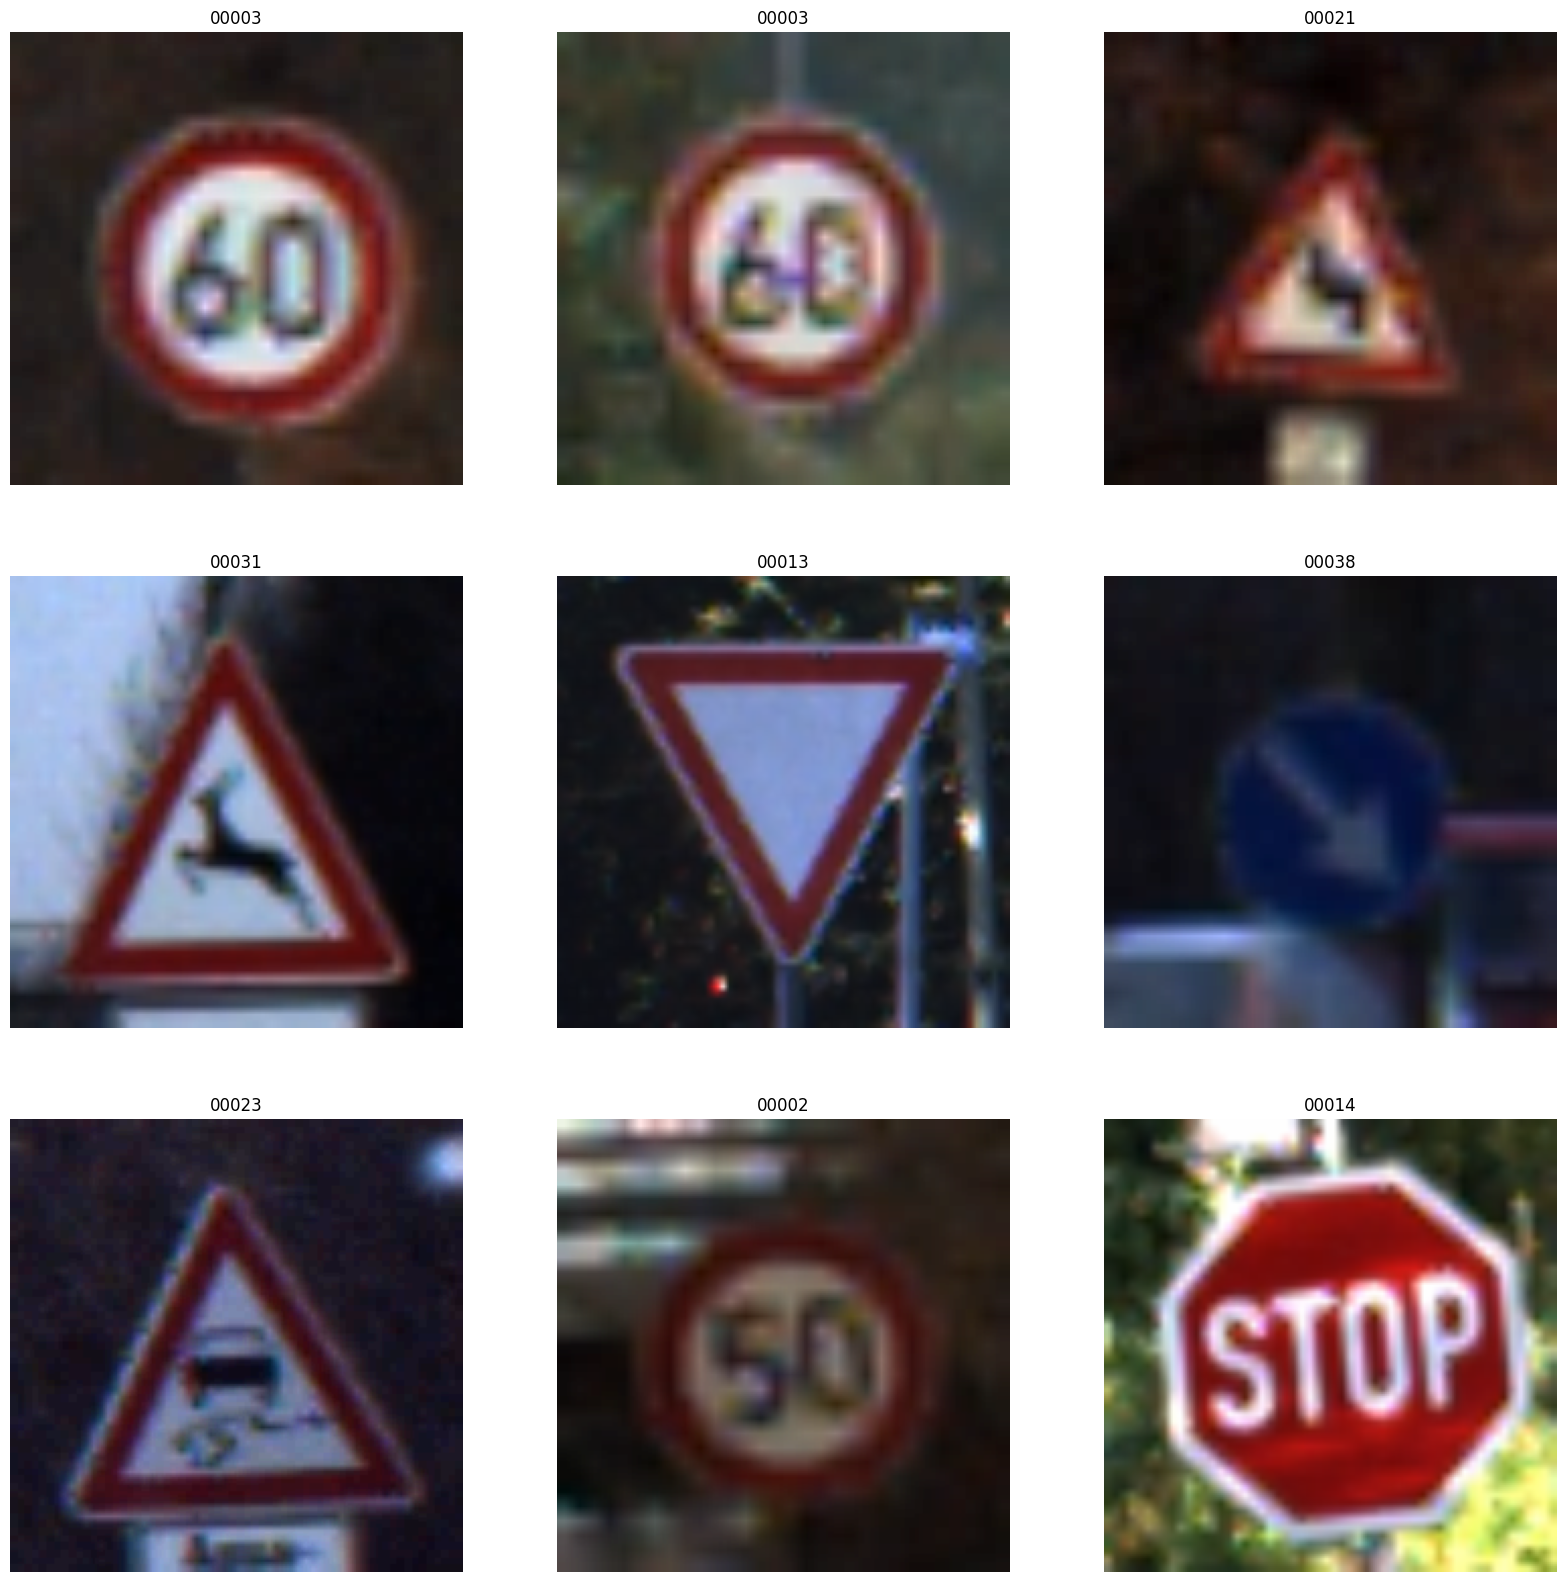

In [15]:
classes = trainset.classes

plot_images(batch[0], batch[1], classes)

## model

In [16]:
pip install timm

In [17]:
pip install einops

In [18]:
# from LNL import LNL_Ti as small

from LNL_TS import LNL_Ti as small

/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/content/Locality-iN-Locality/models/deit.py:78: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit.deit_tiny_patch16_224. This is because the name being registered

In [19]:
model = small(pretrained=False)

In [20]:
model.head

Linear(in_features=192, out_features=43, bias=True)

In [21]:
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [22]:
model = model.cuda()

## Train Locality-iN-Locality

In [26]:
num_epochs = 10

In [27]:
# loss = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

loss = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=5e-2,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
)

In [28]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (batch_images, batch_labels) in enumerate(train_loader):
        X = batch_images.cuda()
        Y = batch_labels.cuda()

        pre = model(X)
        cost = loss(pre, Y)

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

    scheduler.step()

Epoch [1/10], lter [200/3920], Loss: 0.759035
Epoch [1/10], lter [400/3920], Loss: 0.653924
Epoch [1/10], lter [600/3920], Loss: 0.429995
Epoch [1/10], lter [800/3920], Loss: 0.827182
Epoch [1/10], lter [1000/3920], Loss: 0.434961
Epoch [1/10], lter [1200/3920], Loss: 0.441520
Epoch [1/10], lter [1400/3920], Loss: 0.505838
Epoch [1/10], lter [1600/3920], Loss: 0.429518
Epoch [1/10], lter [1800/3920], Loss: 0.457390
Epoch [1/10], lter [2000/3920], Loss: 0.407749
Epoch [1/10], lter [2200/3920], Loss: 0.458431
Epoch [1/10], lter [2400/3920], Loss: 0.409126
Epoch [1/10], lter [2600/3920], Loss: 0.397470
Epoch [1/10], lter [2800/3920], Loss: 0.401345
Epoch [1/10], lter [3000/3920], Loss: 0.399035
Epoch [1/10], lter [3200/3920], Loss: 0.405106
Epoch [1/10], lter [3400/3920], Loss: 0.402197
Epoch [1/10], lter [3600/3920], Loss: 0.414032
Epoch [1/10], lter [3800/3920], Loss: 0.411451
Epoch [2/10], lter [200/3920], Loss: 0.391748
Epoch [2/10], lter [400/3920], Loss: 0.391899
Epoch [2/10], lter 

## Test

In [29]:
model.eval()
correct = 0
total = 0

for images, labels in test_loader:

    images = images.cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

Standard accuracy: 98.99 %


## FGSM attack

In [30]:
model.eval()

correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 71.12 %


## PGD attack

In [31]:
model.eval()

correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 14.43 %


## train LNL-MoEx

In [32]:
# from LNL_MoEx import LNL_MoEx_Ti as small
from LNL_TS import LNL_MoEx_Ti as small
model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [33]:
model = model.cuda()

In [34]:
import time
# time.clock_gettime()

In [35]:
num_epochs = 10
moex_lam = .9
moex_prob = .7

In [36]:
# loss = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

loss = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=5e-2,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
)

In [37]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (input, target) in enumerate(train_loader):
        input = input.cuda()
        target = target.cuda()

        prob = torch.rand(1).item()
        if prob < moex_prob:
            swap_index = torch.randperm(input.size(0), device=input.device)
            with torch.no_grad():
                target_a = target
                target_b = target[swap_index]
            output = model(input, swap_index=swap_index, moex_norm='pono', moex_epsilon=1e-5,
                           moex_layer='stem', moex_positive_only=False)
            lam = moex_lam
            cost = loss(output, target_a) * lam + loss(output, target_b) * (1. - lam)
        else:
            # compute output
            output = model(input)
            # if args.prof >= 0: torch.cuda.nvtx.range_pop()
            cost = loss(output, target)

        # compute gradient and do SGD step

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

    scheduler.step()

Epoch [1/10], lter [200/3920], Loss: 3.541274
Epoch [1/10], lter [400/3920], Loss: 2.801487
Epoch [1/10], lter [600/3920], Loss: 2.165782
Epoch [1/10], lter [800/3920], Loss: 1.952424
Epoch [1/10], lter [1000/3920], Loss: 1.179989
Epoch [1/10], lter [1200/3920], Loss: 0.463348
Epoch [1/10], lter [1400/3920], Loss: 0.985336
Epoch [1/10], lter [1600/3920], Loss: 0.506079
Epoch [1/10], lter [1800/3920], Loss: 1.069942
Epoch [1/10], lter [2000/3920], Loss: 1.050099
Epoch [1/10], lter [2200/3920], Loss: 0.521447
Epoch [1/10], lter [2400/3920], Loss: 0.947316
Epoch [1/10], lter [2600/3920], Loss: 0.968552
Epoch [1/10], lter [2800/3920], Loss: 0.408232
Epoch [1/10], lter [3000/3920], Loss: 0.809920
Epoch [1/10], lter [3200/3920], Loss: 0.986298
Epoch [1/10], lter [3400/3920], Loss: 0.431435
Epoch [1/10], lter [3600/3920], Loss: 0.903664
Epoch [1/10], lter [3800/3920], Loss: 1.054175
Epoch [2/10], lter [200/3920], Loss: 0.492361
Epoch [2/10], lter [400/3920], Loss: 0.896433
Epoch [2/10], lter 

## Save pretrained model for submission

Run this after training the selected model. The saved `.pth` file is the pretrained model submitted with `LNL_TS.py`.


In [38]:
import os

os.makedirs('pretrained', exist_ok=True)
torch.save(model.state_dict(), 'pretrained/lnl_ts_ti_gtsrb.pth')
print('Saved pretrained model to pretrained/lnl_ts_ti_gtsrb.pth')

Saved pretrained model to pretrained/lnl_ts_ti_gtsrb.pth


## Verify plug-and-play pretrained loading

This is the minimal checker code: same model file, local pretrained weights, then the original evaluation loop can be reused.


In [39]:
from LNL_TS import LNL_MoEx_Ti as small

model = small(pretrained=True)
model = model.cuda()
model.eval()
print('Loaded pretrained LNL-TS model successfully')

Loaded pretrained LNL-TS model successfully


In [40]:
# from LNL_TS import LNL_MoEx_Ti as small
# import torch

# test_loader = torch.utils.data.DataLoader(
#     dataset=testset,
#     batch_size=batch_size,
#     shuffle=False
# )

# model = small(pretrained=True)
# model = model.cuda()
# model.eval()

# correct = 0
# total = 0

# with torch.no_grad():
#     for images, labels in test_loader:
#         images = images.cuda()
#         labels = labels.cuda()

#         outputs = model(images)
#         predicted = outputs.argmax(dim=1)

#         total += labels.size(0)
#         correct += predicted.eq(labels).sum().item()

# print('Reloaded pretrained Top-1 accuracy: %.2f %%' % (100.0 * correct / total))

from LNL_TS import LNL_MoEx_Ti as small
import torch

test_loader = torch.utils.data.DataLoader(
    dataset=testset,
    batch_size=batch_size * 2,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

model = small(pretrained=True)
model = model.cuda()
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)
        predicted = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print('Reloaded pretrained Top-1 accuracy: %.2f %%' % (100.0 * correct / total))

Reloaded pretrained Top-1 accuracy: 99.09 %


## Number of Parameters

In [ ]:
pip install ptflops

In [ ]:
pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

In [43]:
import torch
from ptflops import get_model_complexity_info

with torch.cuda.device(0):
  net = model
  macs, params = get_model_complexity_info(net, (3, 224, 224), as_strings=True,
                                           print_per_layer_stat=True, verbose=True)
  print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
  print('{:<30}  {:<8}'.format('Number of parameters: ', params))


TrafficSignLNL(
  6.04 M, 99.371% Params, 1.24 GMac, 99.695% MACs, 
  (pixel_embed): PixelEmbed(
    648, 0.011% Params, 5.49 MMac, 0.440% MACs, 
    (proj): TrafficSignStem(
      648, 0.011% Params, 5.49 MMac, 0.440% MACs, 
      (conv1): Conv2d(324, 0.005% Params, 4.06 MMac, 0.326% MACs, 3, 12, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(24, 0.000% Params, 301.06 KMac, 0.024% MACs, 12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): GELU(0, 0.000% Params, 150.53 KMac, 0.012% MACs, approximate='none')
      (dwconv): Conv2d(108, 0.002% Params, 338.69 KMac, 0.027% MACs, 12, 12, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=12, bias=False)
      (bn2): BatchNorm2d(24, 0.000% Params, 75.26 KMac, 0.006% MACs, 12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): GELU(0, 0.000% Params, 37.63 KMac, 0.003% MACs, approximate='none')
      (pwconv): Conv2d(144, 0.002% Params, 451.